In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

from attrition_analysis.models_utils import (
    estimators_dict,
    mixed_models_dict_c,
    categorical_models_dict_c,
    prepare_model_data,
    run_cross_validation_mixed,
    run_model_comparison_mixed,
)


df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

random_forest_estimators_dict = {
    "Random Forest": estimators_dict["Random Forest"],
    "Random Forest Balanced": estimators_dict["Random Forest Balanced"]
}

In [2]:
all_models_dict_c = {**categorical_models_dict_c, **mixed_models_dict_c}

In [3]:
general_comparison_rf, threshold_comparison_rf, confusion_results_rf, trained_models_rf, interpretation_results_rf = run_model_comparison_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict=random_forest_estimators_dict,
    target=target
)

general_comparison_rf.sort_values(by=["F1-score", "AUC"], ascending=False)


,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
9,Modelo 5 — Estabilidade e Benefícios,Random Forest Balanced,0.5,0.780,0.402,0.746,0.522,0.798,0,9,24
19,Modelo 3 — Rendimento Quantitativo,Random Forest Balanced,0.5,0.807,0.429,0.592,0.497,0.792,4,6,19
29,Modelo 8 — Integrado Multidimensional,Random Forest Balanced,0.5,0.798,0.413,0.606,0.491,0.787,7,11,43
17,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest Balanced,0.5,0.794,0.406,0.606,0.486,0.813,3,8,25
11,Modelo 6 — Perfil Pessoal,Random Forest Balanced,0.5,0.780,0.386,0.620,0.476,0.793,0,9,24
15,Modelo 1 — Função Profissional Misto,Random Forest Balanced,0.5,0.773,0.378,0.634,0.474,0.778,3,7,26
13,Modelo 7 — Reduzido Conservador,Random Forest Balanced,0.5,0.757,0.364,0.676,0.473,0.757,0,7,18
7,Modelo 4 — Trajetória Organizacional,Random Forest Balanced,0.5,0.766,0.371,0.648,0.472,0.753,0,8,22
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Random Forest Balanced,0.5,0.791,0.398,0.577,0.471,0.804,3,8,24
27,Modelo 7 — Reduzido Conservador Misto,Random Forest Balanced,0.5,0.771,0.375,0.634,0.471,0.770,3,6,18


In [4]:
best_thresholds_rf = threshold_comparison_rf.loc[
    threshold_comparison_rf.groupby(["Variable_Set", "Model"])["F1-score"].idxmax()
].reset_index(drop=True)

best_thresholds_rf.sort_values(by="F1-score", ascending=False)

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
19,Modelo 5 — Estabilidade e Benefícios,Random Forest Balanced,0.525,0.807,0.438,0.690,0.536,0.798
5,Modelo 2 — Nível Hierárquico,Random Forest Balanced,0.600,0.855,0.554,0.507,0.529,0.802
7,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest Balanced,0.550,0.841,0.506,0.549,0.527,0.813
6,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest,0.275,0.859,0.576,0.479,0.523,0.809
29,Modelo 8 — Integrado Multidimensional,Random Forest Balanced,0.450,0.771,0.391,0.761,0.517,0.787
21,Modelo 6 — Perfil Pessoal,Random Forest Balanced,0.550,0.837,0.494,0.535,0.514,0.793
28,Modelo 8 — Integrado Multidimensional,Random Forest,0.200,0.794,0.414,0.676,0.513,0.795
9,Modelo 3 — Faixa Salarial,Random Forest Balanced,0.650,0.868,0.638,0.423,0.508,0.783
18,Modelo 5 — Estabilidade e Benefícios,Random Forest,0.200,0.785,0.402,0.690,0.508,0.802
22,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Random Forest,0.225,0.830,0.475,0.535,0.503,0.796


In [5]:
top_5_best_rf = best_thresholds_rf.sort_values(by="F1-score", ascending=False).head(5).reset_index(drop=True)

top_5_best_rf

,Variable_Set,Model,Threshold,Accuracy,Precision,Recall,F1-score,AUC
0,Modelo 5 — Estabilidade e Benefícios,Random Forest Balanced,0.525,0.807,0.438,0.690,0.536,0.798
1,Modelo 2 — Nível Hierárquico,Random Forest Balanced,0.600,0.855,0.554,0.507,0.529,0.802
2,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest Balanced,0.550,0.841,0.506,0.549,0.527,0.813
3,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest,0.275,0.859,0.576,0.479,0.523,0.809
4,Modelo 8 — Integrado Multidimensional,Random Forest Balanced,0.450,0.771,0.391,0.761,0.517,0.787


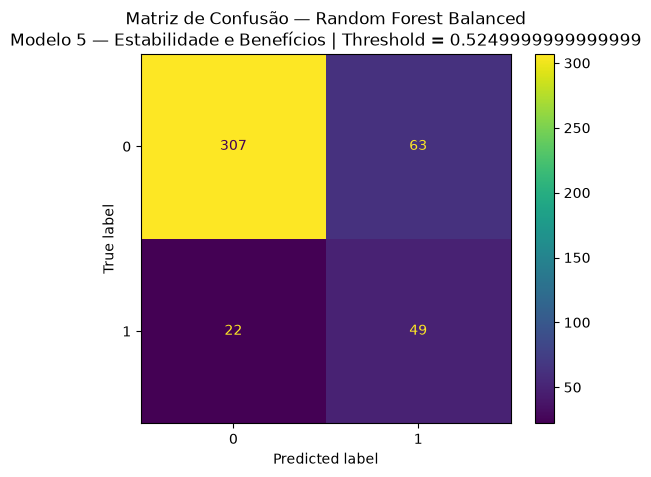

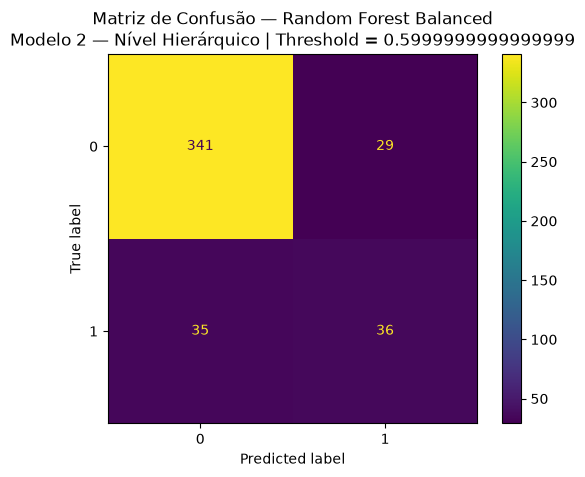

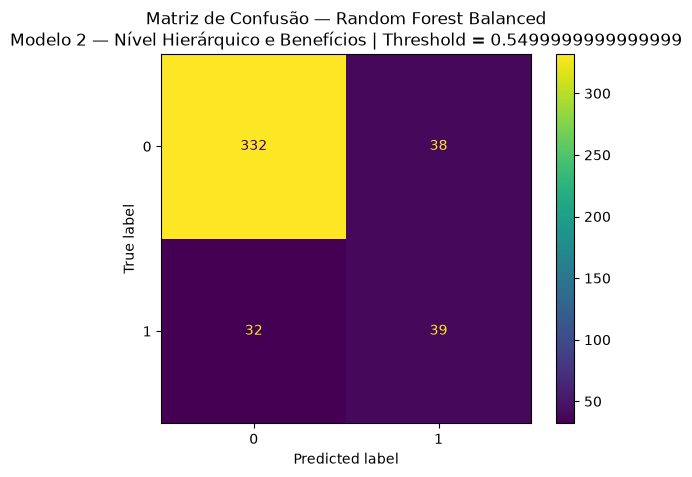

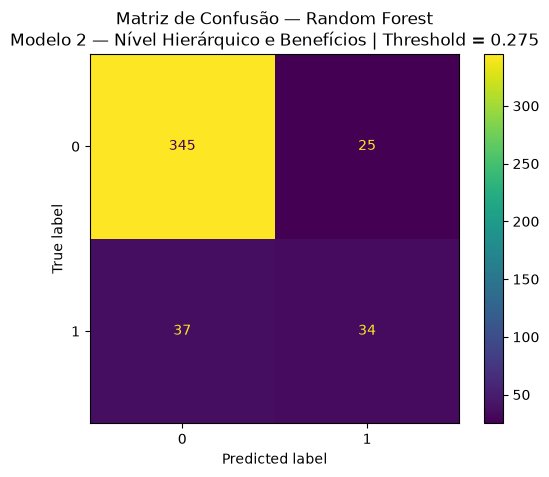

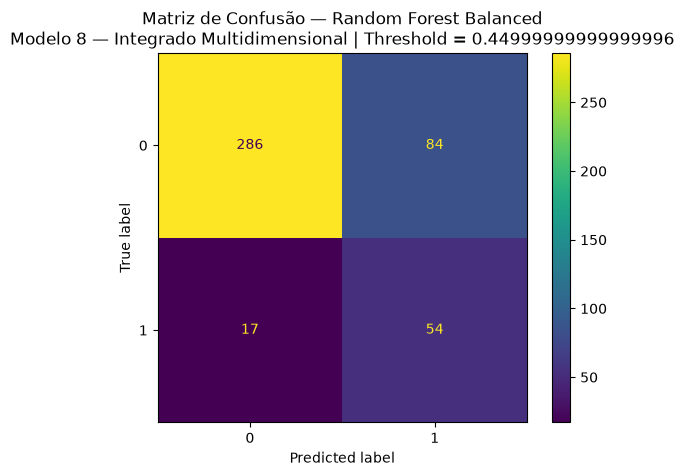

In [6]:
for _, row in top_5_best_rf.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    best_threshold = row["Threshold"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(random_forest_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train, y_train)
    
    y_prob = estimator.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de Confusão — {model_name}\n{variable_set_name} | Threshold = {best_threshold}")
    plt.show()

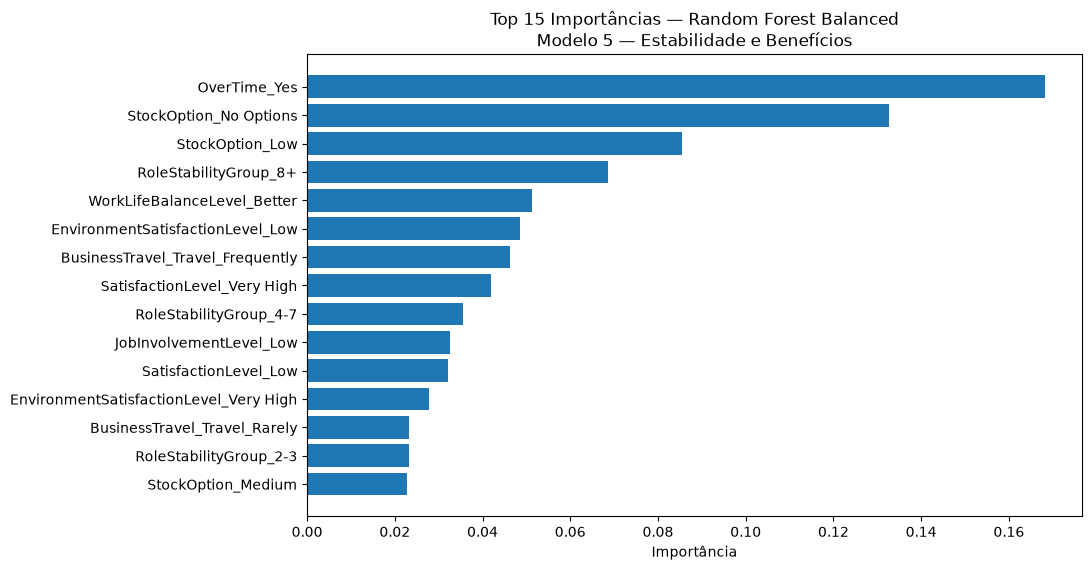

,Feature,Importance
0,OverTime_Yes,0.168274
6,StockOption_No Options,0.132626
4,StockOption_Low,0.085583
3,RoleStabilityGroup_8+,0.068525
19,WorkLifeBalanceLevel_Better,0.051244
12,EnvironmentSatisfactionLevel_Low,0.048555
7,BusinessTravel_Travel_Frequently,0.046284
17,SatisfactionLevel_Very High,0.041843
2,RoleStabilityGroup_4-7,0.035514
9,JobInvolvementLevel_Low,0.032695


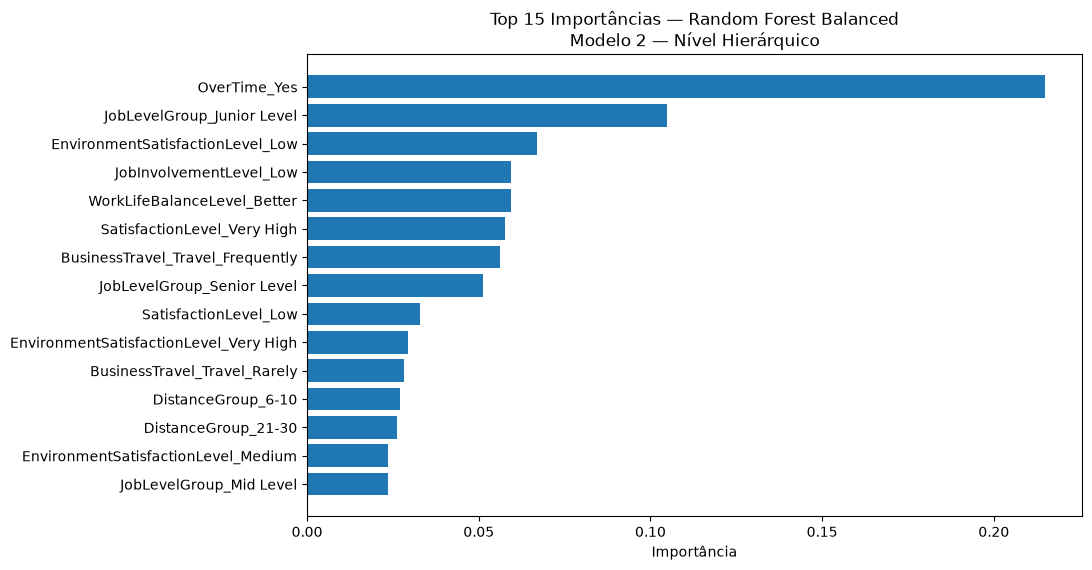

,Feature,Importance
0,OverTime_Yes,0.214955
2,JobLevelGroup_Junior Level,0.104788
10,EnvironmentSatisfactionLevel_Low,0.066987
7,JobInvolvementLevel_Low,0.059419
17,WorkLifeBalanceLevel_Better,0.059311
15,SatisfactionLevel_Very High,0.057715
5,BusinessTravel_Travel_Frequently,0.056147
4,JobLevelGroup_Senior Level,0.051255
13,SatisfactionLevel_Low,0.032842
12,EnvironmentSatisfactionLevel_Very High,0.029306


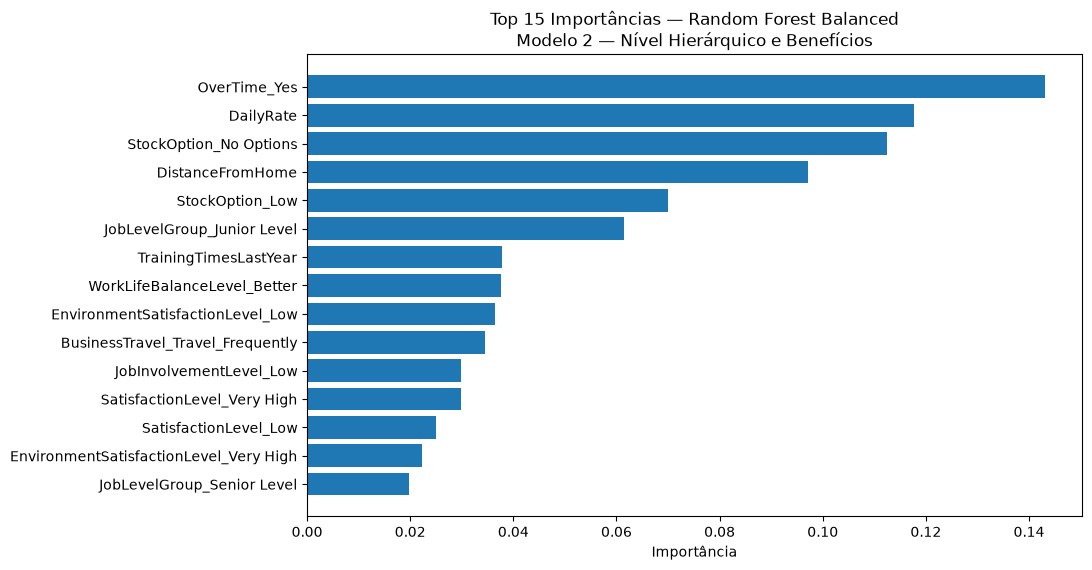

,Feature,Importance
3,OverTime_Yes,0.143135
1,DailyRate,0.117635
10,StockOption_No Options,0.112370
0,DistanceFromHome,0.097193
8,StockOption_Low,0.070025
5,JobLevelGroup_Junior Level,0.061504
2,TrainingTimesLastYear,0.037846
23,WorkLifeBalanceLevel_Better,0.037606
16,EnvironmentSatisfactionLevel_Low,0.036536
11,BusinessTravel_Travel_Frequently,0.034479


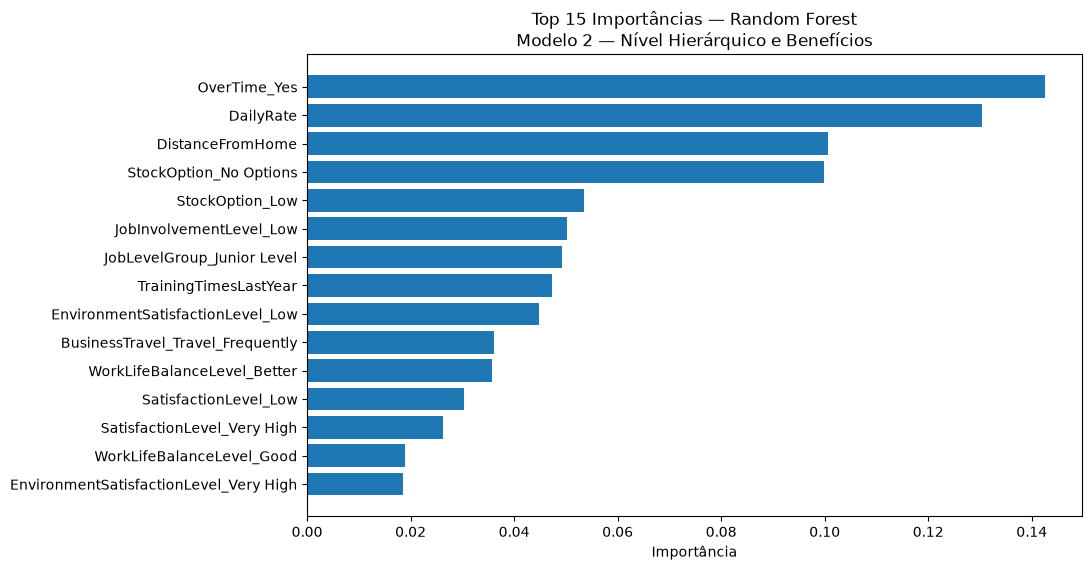

,Feature,Importance
3,OverTime_Yes,0.142588
1,DailyRate,0.130414
0,DistanceFromHome,0.100694
10,StockOption_No Options,0.099876
8,StockOption_Low,0.053458
13,JobInvolvementLevel_Low,0.050263
5,JobLevelGroup_Junior Level,0.049329
2,TrainingTimesLastYear,0.047287
16,EnvironmentSatisfactionLevel_Low,0.044794
11,BusinessTravel_Travel_Frequently,0.036108


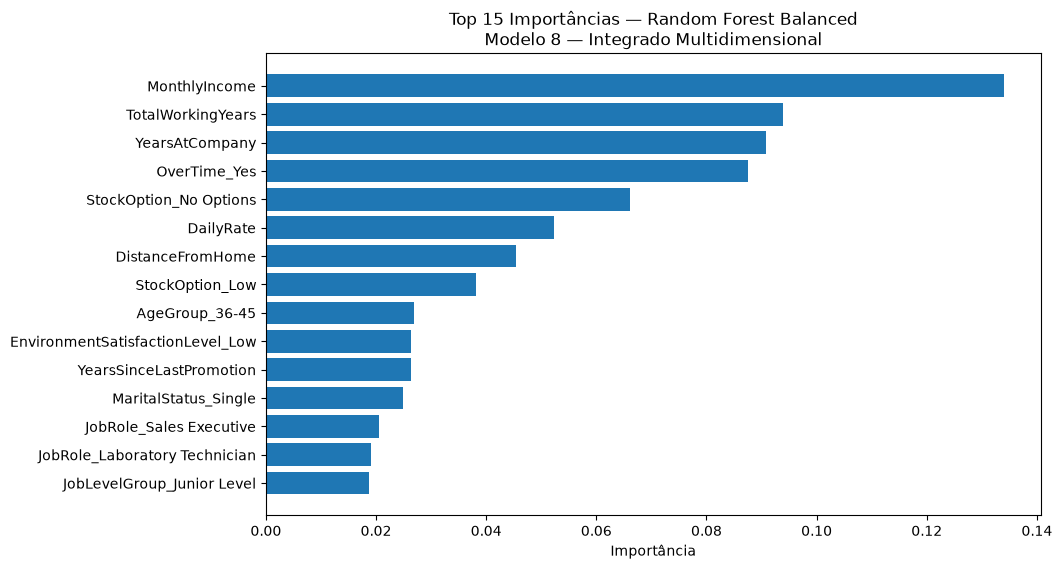

,Feature,Importance
0,MonthlyIncome,0.134024
1,TotalWorkingYears,0.093872
2,YearsAtCompany,0.090771
7,OverTime_Yes,0.087584
22,StockOption_No Options,0.066167
5,DailyRate,0.052323
4,DistanceFromHome,0.045433
20,StockOption_Low,0.038172
24,AgeGroup_36-45,0.026922
34,EnvironmentSatisfactionLevel_Low,0.026367


In [7]:
for _, row in top_5_best_rf.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    importance_df = interpretation_results_rf[variable_set_name][model_name].copy()
    
    top_importance = importance_df.head(15).sort_values(by="Importance", ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(top_importance["Feature"], top_importance["Importance"])
    plt.xlabel("Importância")
    plt.title(f"Top 15 Importâncias — {model_name}\n{variable_set_name}")
    plt.show()
    
    display(importance_df.head(20))

SHAP — Random Forest Balanced | Modelo 5 — Estabilidade e Benefícios
(441, 24)
(441, 24)


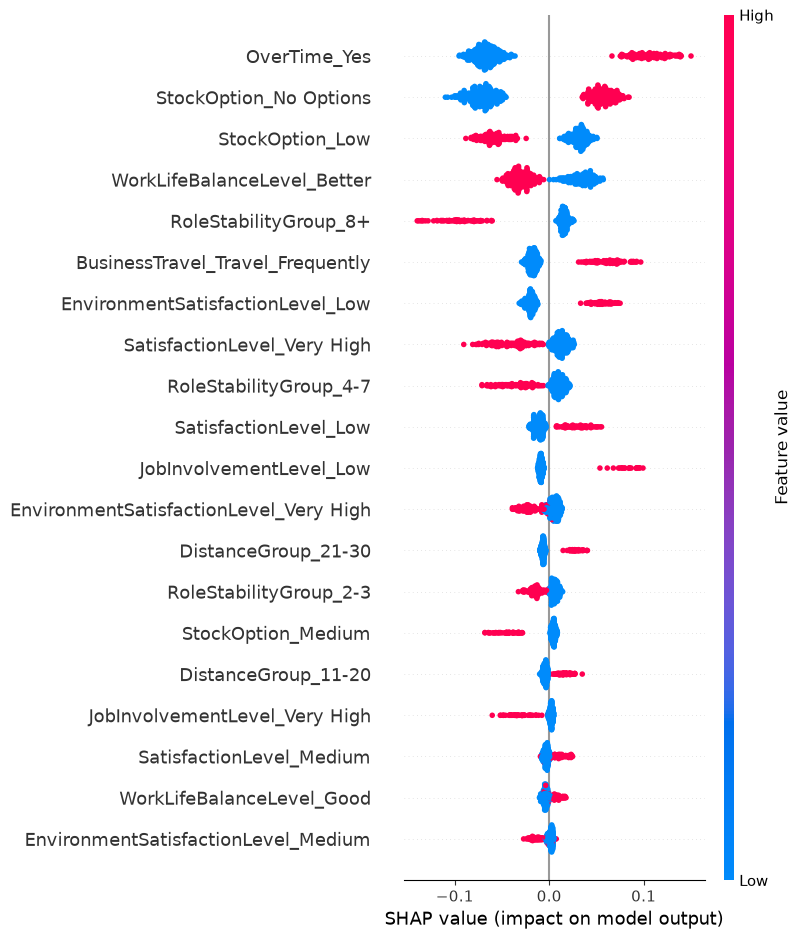

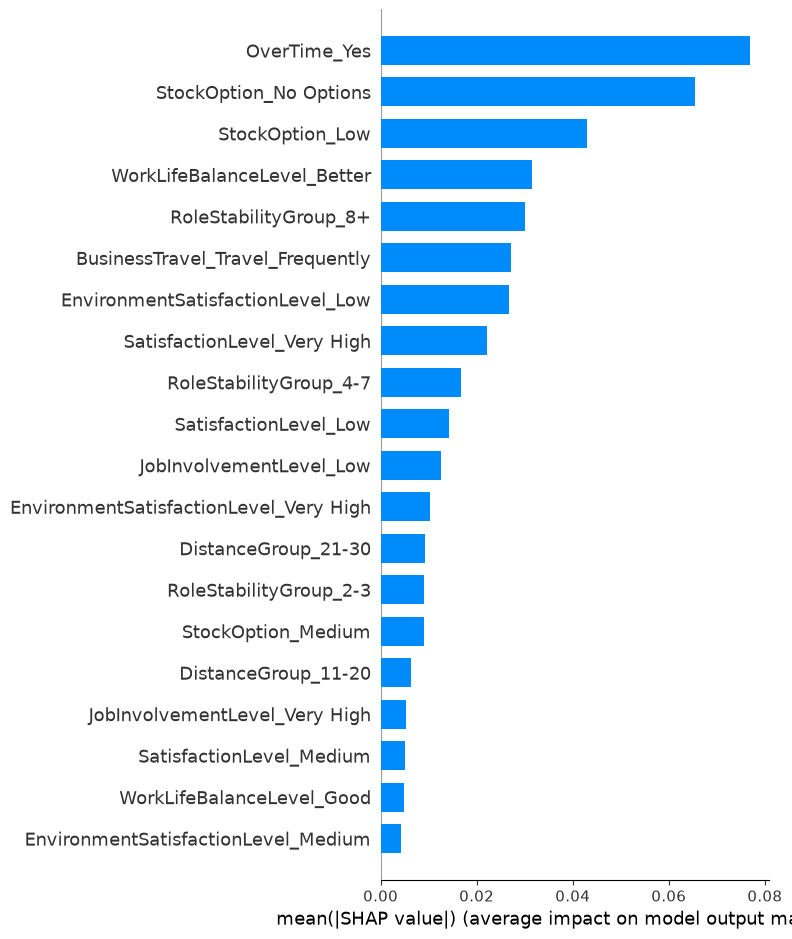

SHAP — Random Forest Balanced | Modelo 2 — Nível Hierárquico
(441, 22)
(441, 22)


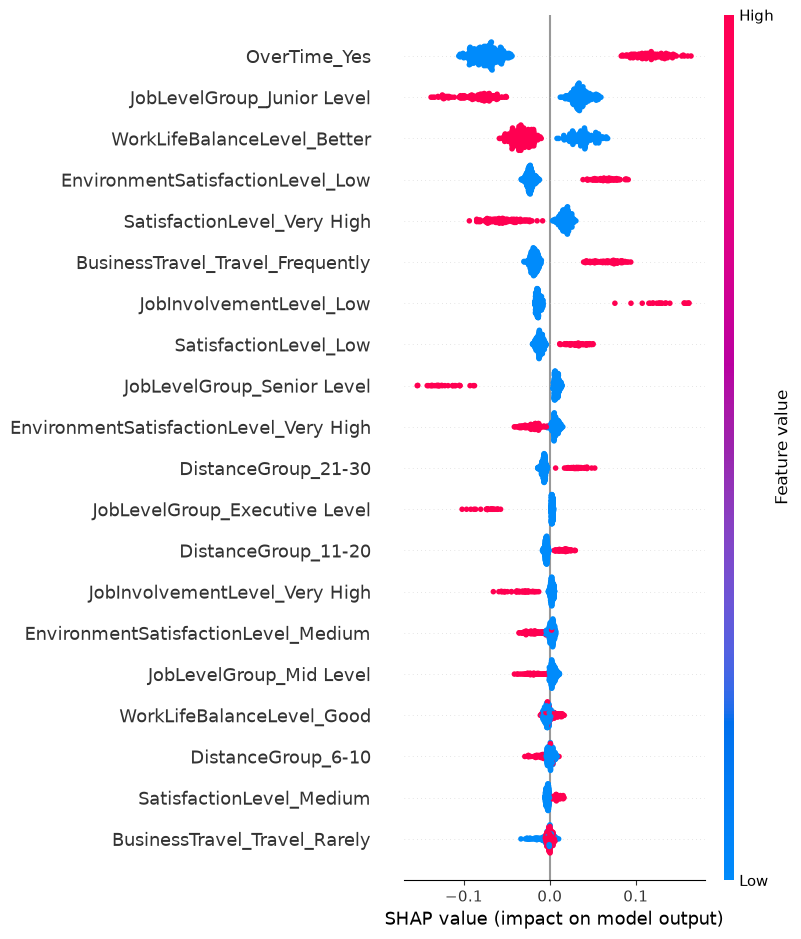

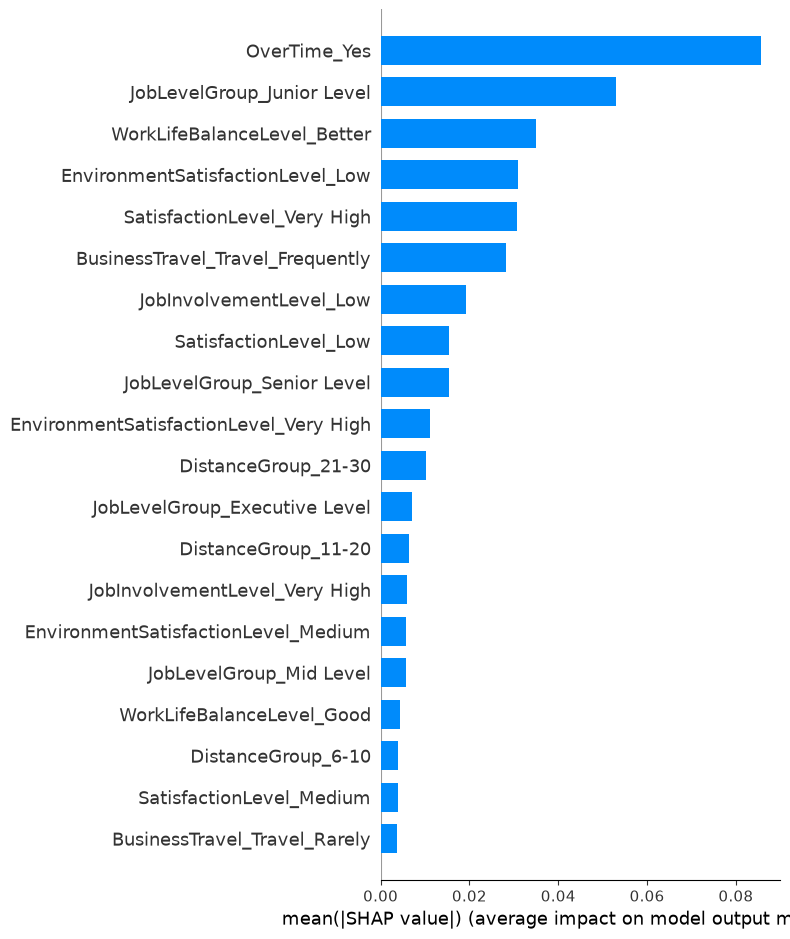

SHAP — Random Forest Balanced | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


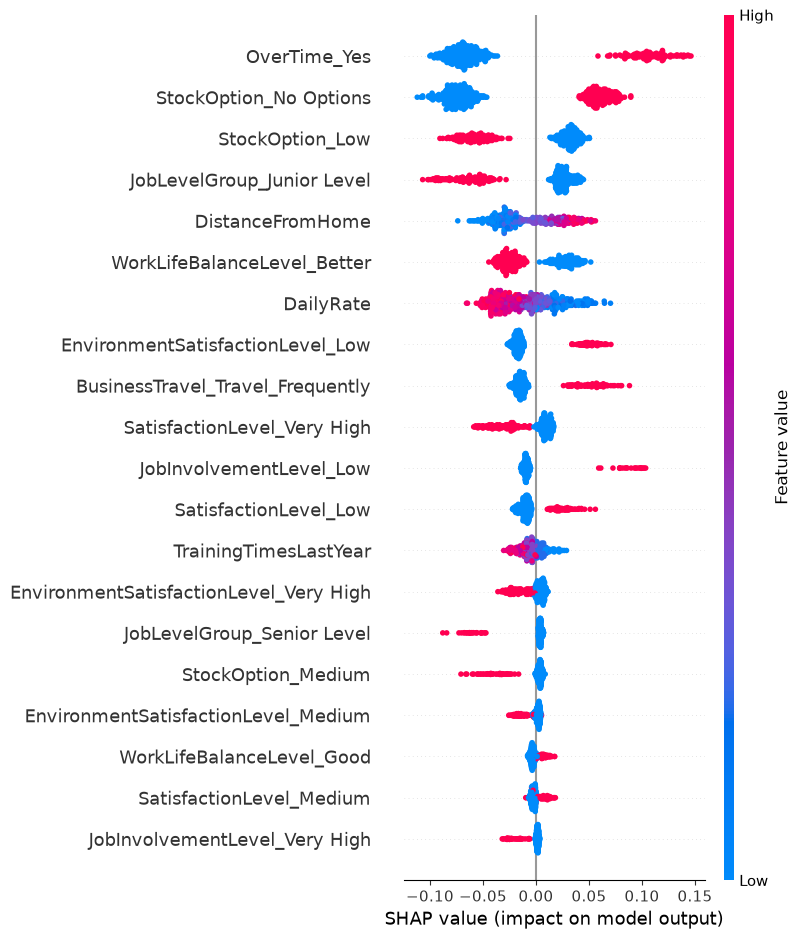

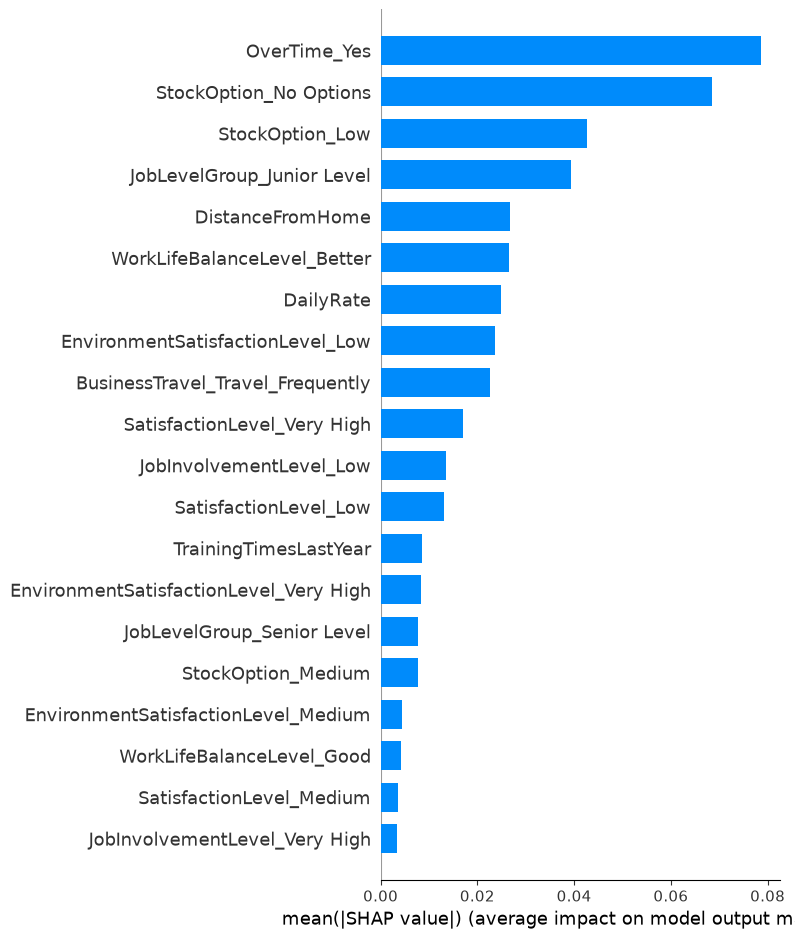

SHAP — Random Forest | Modelo 2 — Nível Hierárquico e Benefícios
(441, 25)
(441, 25)


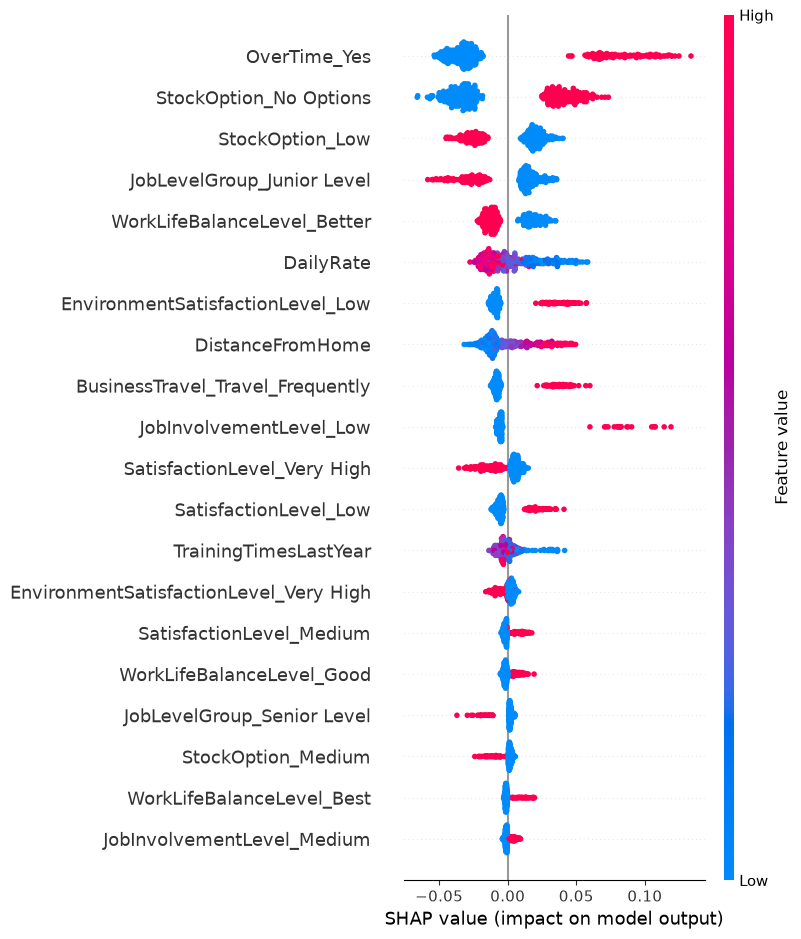

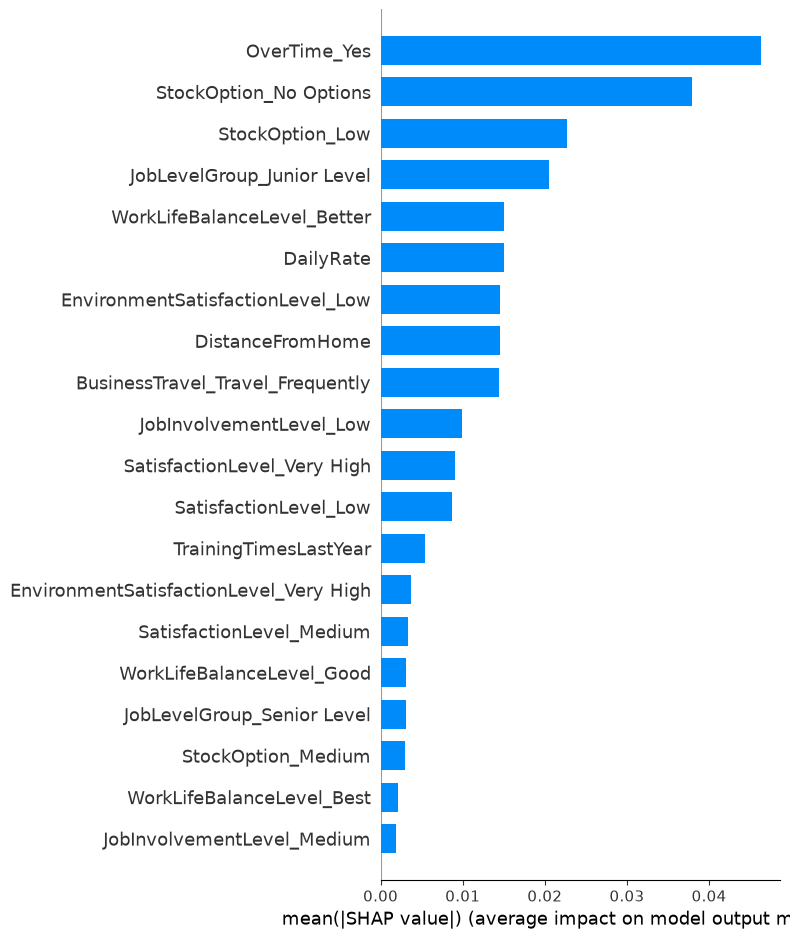

SHAP — Random Forest Balanced | Modelo 8 — Integrado Multidimensional
(441, 43)
(441, 43)


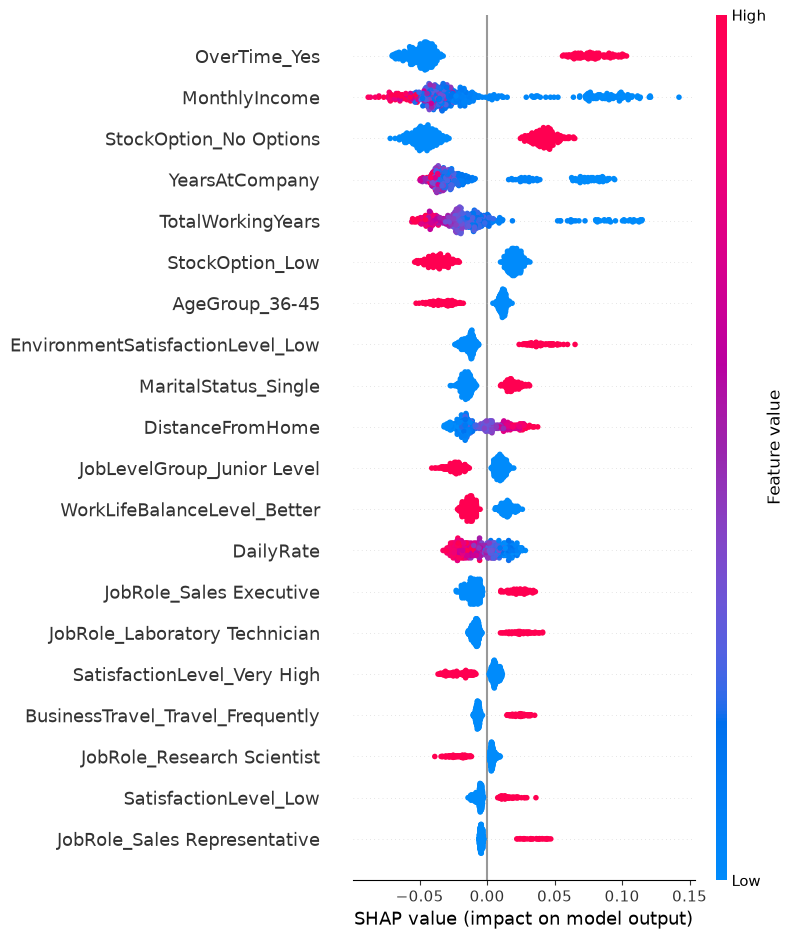

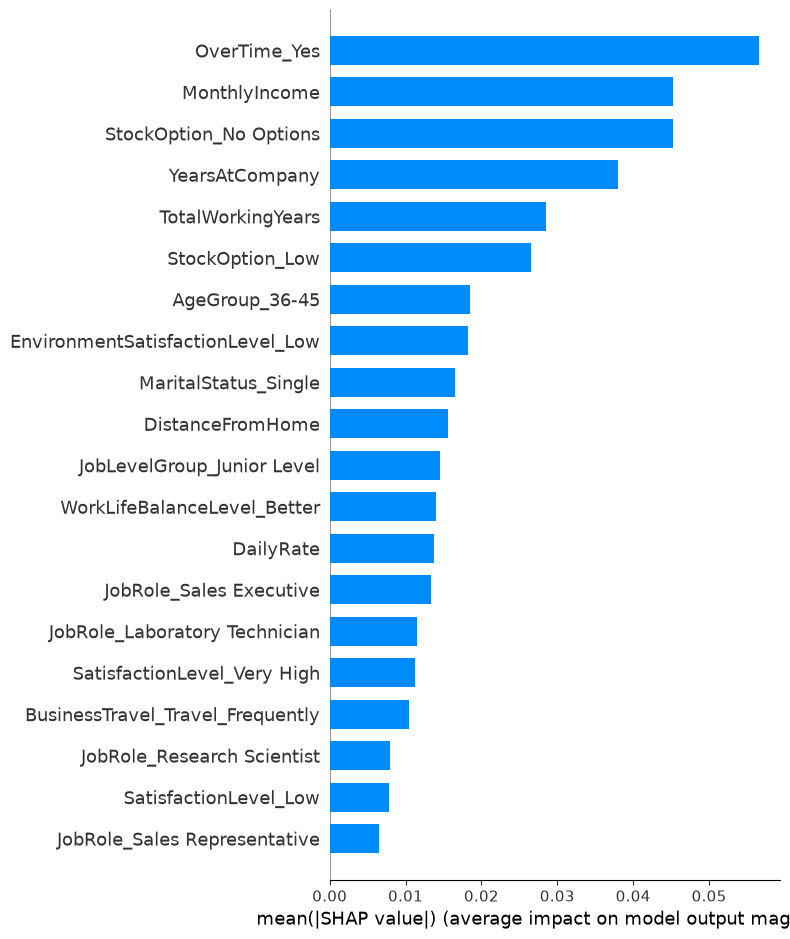

In [8]:
for _, row in top_5_best_rf.iterrows():
    
    variable_set_name = row["Variable_Set"]
    model_name = row["Model"]
    
    model_info = all_models_dict_c[variable_set_name]
    numeric_vars = model_info["numeric_vars"]
    categorical_vars = model_info["categorical_vars"]
    
    X, y = prepare_model_data(
        df=df,
        numeric_vars=numeric_vars,
        categorical_vars=categorical_vars,
        target=target
    )
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
    
    estimator = clone(random_forest_estimators_dict[model_name]["estimator"])
    estimator.fit(X_train, y_train)
    
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        shap_values_class1 = shap_values[1]
    elif len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values
    
    print(f"SHAP — {model_name} | {variable_set_name}")
    print(shap_values_class1.shape)
    print(X_test.shape)
    
    shap.summary_plot(shap_values_class1, X_test)
    shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# Validação Cruzada

In [9]:
cv_random_forest = run_cross_validation_mixed(
    df=df,
    models_dict=all_models_dict_c,
    estimators_dict={
        "Random Forest": estimators_dict["Random Forest"],
        "Random Forest Balanced": estimators_dict["Random Forest Balanced"]
    },
    target="AttritionFlag"
)

cv_random_forest.sort_values("F1_Mean", ascending=False)

,Variable_Set,Model,Accuracy_Mean,Accuracy_Std,Precision_Mean,Precision_Std,Recall_Mean,Recall_Std,F1_Mean,F1_Std,AUC_Mean,AUC_Std,N_Numeric_Variables,N_Categorical_Variables,N_Features_After_Dummies
29,Modelo 8 — Integrado Multidimensional,Random Forest Balanced,0.796,0.024,0.412,0.048,0.607,0.080,0.489,0.053,0.806,0.040,7,11,43
19,Modelo 3 — Rendimento Quantitativo,Random Forest Balanced,0.784,0.032,0.395,0.059,0.594,0.058,0.472,0.051,0.774,0.051,4,6,19
7,Modelo 4 — Trajetória Organizacional,Random Forest Balanced,0.758,0.038,0.367,0.057,0.662,0.076,0.470,0.058,0.769,0.037,0,8,22
9,Modelo 5 — Estabilidade e Benefícios,Random Forest Balanced,0.763,0.028,0.369,0.046,0.649,0.079,0.469,0.052,0.775,0.044,0,9,24
17,Modelo 2 — Nível Hierárquico e Benefícios,Random Forest Balanced,0.771,0.031,0.373,0.051,0.598,0.094,0.457,0.058,0.777,0.050,3,8,25
15,Modelo 1 — Função Profissional Misto,Random Forest Balanced,0.758,0.020,0.357,0.038,0.632,0.086,0.456,0.051,0.764,0.050,3,7,26
5,Modelo 3 — Faixa Salarial,Random Forest Balanced,0.753,0.040,0.356,0.055,0.636,0.100,0.455,0.062,0.766,0.059,0,8,21
23,Modelo 5 — Antiguidade Organizacional,Random Forest Balanced,0.763,0.034,0.364,0.048,0.607,0.072,0.453,0.050,0.754,0.045,5,6,20
25,Modelo 6 — Perfil Pessoal e Condições de Trabalho,Random Forest Balanced,0.771,0.028,0.367,0.050,0.586,0.111,0.450,0.068,0.772,0.063,3,8,24
21,Modelo 4 — Experiência Profissional,Random Forest Balanced,0.764,0.039,0.365,0.049,0.595,0.072,0.450,0.049,0.766,0.045,4,6,19
